# Assignment 2: The "Smart Labeling Pipeline" Challenge

**Total Marks: 20**

Build a cost-effective, high-quality labeling pipeline using human annotation, programmatic rules, and LLMs.

This notebook implements an end-to-end smart labeling pipeline to:
1. Establish gold standard through human annotation and measure inter-annotator agreement (6 marks)
2. Label data programmatically using weak supervision (Snorkel) (6 marks)
3. Optimize labeling budget using active learning (5 marks)
4. Leverage LLMs for bulk labeling and detect hallucinations (e.g. noisy labels) (3 marks)

## Setup and Imports

In [1]:
#Turning off warnings
import warnings
warnings.filterwarnings("ignore")
# Import required libraries
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from snorkel.labeling import labeling_function, PandasLFApplier, LFAnalysis
from snorkel.labeling.model import LabelModel
from statsmodels.stats.inter_rater import fleiss_kappa
import google.generativeai as genai
import time
from pathlib import Path
import re

## Task 1: The Human as Annotator (6 Marks)

**Objective:** Establish a "Gold Standard" dataset and measure human consensus.

### Part 1.1: Parse Annotator CSV Files

After annotating the first 100 reviews, export annotations from three annotators (A, B, C) as CSV files.
Parse these CSV files into clean DataFrames for analysis.

In [4]:
def parse_annotator_csv(csv_path):
    """
    Parses annotator CSV file into a clean DataFrame.
    
    Args:
        csv_path (str): Path to annotator CSV file
        
    Returns:
        pd.DataFrame: DataFrame with columns ['review_id', 'review', 'label']
                     where label is one of: 'Positive', 'Negative', 'Neutral'
    
    Note:
        - Look for relevant column names in the CSV file
        - If column names differ, the function will try to map them appropriately
        - Finally, return with two columns 'review' and 'label'
    """
    # TODO: Load CSV file using pd.read_csv()
    df = pd.read_csv(csv_path)[['id', 'review', 'sentiment']]

    # TODO: Check and map column names if needed
    df = df.rename(columns={'id' : 'review_id', 'sentiment' : 'label'})

    return df

In [5]:
# TODO: Parse CSV files (replace with actual file paths)
df_A = parse_annotator_csv("annotator_a.csv")
df_B = parse_annotator_csv("annotator_b.csv")
df_C = parse_annotator_csv("annotator_c.csv")

# Display sample data
print("Sample data for annotator A:")
print(df_A.head(),'\n')
print("Sample data for annotator B:")
print(df_B.head(), '\n')
print("Sample data for annotator C:")
print(df_C.head())

Sample data for annotator A:
   review_id                                             review     label
0          1  This movie is a triumph in every sense. Highly...  Positive
1          2  I have never been so bored in my life. The sco...  Negative
2          3  I was completely blown away by this film. The ...  Positive
3          4  The trailer was better than the movie. The act...  Negative
4          5  Middle of the road entertainment. Visually it'...   Neutral 

Sample data for annotator B:
   review_id                                             review     label
0          1  This movie is a triumph in every sense. Highly...  Positive
1          2  I have never been so bored in my life. The sco...  Negative
2          3  I was completely blown away by this film. The ...  Positive
3          4  The trailer was better than the movie. The act...  Negative
4          5  Middle of the road entertainment. Visually it'...   Neutral 

Sample data for annotator C:
   review_id         

### Part 1.2: Implement Fleiss' Kappa from Scratch

Measure inter-annotator agreement using Fleiss' Kappa statistic.
Implement the formula from scratch and compare with statsmodels implementation.

In [6]:
def fleiss_kappa_scratch(rating_matrix):
    """
    Computes Fleiss' Kappa for multiple raters from scratch.
    
    Args:
        rating_matrix (np.array): A Count Matrix of shape (N, k).
                                  - N = number of items (rows)
                                  - k = number of categories (columns)
                                  - Element [i, j] = Count of raters who assigned category j to item i.
                                  Example: 
                                    [[0, 0, 3],   # Item 0: All 3 raters said Category 2
                                     [1, 2, 0]]   # Item 1: 1 rater said Cat 0, 2 said Cat 1
                            
    
    Returns:
        float: Kappa score (ranges from -1 to 1, where 1 = perfect agreement)
    
    Formula:
        κ = (P_bar - P_e_bar) / (1 - P_e_bar)
        
        where:
        - P_bar = (1/N) * Σ(P_i) = average proportion of agreement across all items
        - P_i = (1/(n*(n-1))) * Σ(k_ij * (k_ij - 1)) for item i
        - P_e_bar = Σ(p_j^2) = expected agreement by chance
        - p_j = proportion of all assignments to category j
    
    Note:
        - N = number of items (samples)
        - n = number of raters per item (should be constant)
        - k_ij = number of raters who assigned category j to item i
    """
    # TODO: Calculate P_bar (observed agreement), P_e_bar (expected agreement by chance), Apply the formula: κ = (P_bar - P_e_bar) / (1 - P_e_bar)
    n = sum(rating_matrix[0])
    N, k = np.shape(rating_matrix)

    P_i = np.zeros(N)
    for i in range(N):
        row = rating_matrix[i]
        P_i[i] = np.sum(row  * (row - 1)) / (n * (n-1))
    P_bar = np.mean(P_i)

    p_j = np.sum(rating_matrix, axis = 0) / (N*n)
    P_e_bar = np.sum(p_j ** 2)

    kappa = (P_bar - P_e_bar) / (1 - P_e_bar)
    
    return kappa

In [7]:
def prepare_rating_matrix(df_a, df_b, df_c):
    """
    Converts three DataFrames into a rating matrix for Fleiss' Kappa calculation.
    
    Args:
        df_a, df_b, df_c: DataFrames with columns ['review_id', 'review', 'label']
        
    Returns:
        np.array: Rating matrix of shape (N_samples, N_categories)
                  where categories are ['Negative', 'Neutral', 'Positive']
    """
    # TODO: Merge the three DataFrames on review
    # Hint: Use pd.merge() or pd.concat() with proper keys
    #df = pd.concat([df_a['label'].rename('label_a'), df_b['label'].rename('label_b'), df_c['label'].rename('label_c')], axis=1)
    
    df_a_ = df_a[['review_id', 'label']].rename(columns = {'label' : 'label_a'})
    df_b_ = df_b[['review_id', 'label']].rename(columns = {'label' : 'label_b'})
    df_c_ = df_c[['review_id', 'label']].rename(columns = {'label' : 'label_c'})
    
    df = df_a_.merge(df_b_, on = "review_id", how = 'inner')
    df = df.merge(df_c_, on = "review_id", how = 'inner')
    
    # TODO: Return numpy array of shape (N_samples, 3)
    # Order: [Negative_count, Neutral_count, Positive_count] for each row
    
    categories = ['Negative', 'Neutral', 'Positive']
    rating_matrix = []
    for _, row in df.iterrows():
        counts = [0, 0, 0]
        for label in [row['label_a'], row['label_b'], row['label_c']]:
            if label == 'Negative': counts[0] += 1
            elif label == 'Neutral': counts[1] += 1
            elif label == 'Positive': counts[2] += 1
            else: raise ValueError(f"Unexpected label: {label}")
        rating_matrix.append(counts)
    
    return np.array(rating_matrix)

# TODO: Prepare rating matrix and calculate Fleiss' Kappa
df = prepare_rating_matrix(df_A, df_B, df_C)
f_kappa = fleiss_kappa_scratch(df)

# TODO: Use statsmodels to calculate Fleiss' Kappa
sm_f_kappa = fleiss_kappa(df, method='fleiss')

# TODO: Print the difference between the two implementations
print(f"Scratch: {f_kappa:.5f}")
print(f"Statsmodels: {sm_f_kappa:.5f}")
print(f"Difference: {abs(f_kappa - sm_f_kappa):.5f}")

Scratch: 0.81647
Statsmodels: 0.81647
Difference: 0.00000


### Part 1.3: Conflict Resolution

Identify conflicts where annotators disagree and resolve them using majority vote.
For complete ties (all three differ), default to 'Neutral'.

In [8]:
def helper(row):
    if ((row['label_a'] == row['label_b']) | (row['label_a'] == row['label_c'])): return row['label_a']
    elif (row['label_b'] == row['label_c']): return row['label_b']
    else: return "Neutral"
        

def resolve_conflicts(df_a, df_b, df_c):
    """
    Merges annotations from 3 annotators, resolves disagreements using Majority Vote,
    and handles complete ties by defaulting to 'Neutral'.
    
    Args:
        df_a, df_b, df_c: DataFrames from each annotator with columns ['review', 'label']
        
    Returns:
        pd.DataFrame: Final DataFrame with resolved labels (gold standard)
                     Columns: ['review', 'label']
    
    Logic:
        - Majority Vote: If 2 annotators agree, use their label
        - Tie-Breaker: If all 3 differ (e.g., Positive vs. Negative vs. Neutral), assign 'Neutral'
    """
    df = df_a.copy()
    df.rename(columns = {'label' : 'label_a'}, inplace = True)

    df = df.merge(df_b.rename(columns = {'label' : 'label_b'}), on = 'review', how = 'inner')
    df = df.merge(df_c.rename(columns = {'label' : 'label_c'}), on = 'review', how = 'inner')

    df['label'] = df.apply(helper, axis = 1)
    
    return df[['review', 'label']]

In [9]:
# TODO: Resolve conflicts and create gold standard
df_gold_st = resolve_conflicts(df_A, df_B, df_C)

# TODO: Display 5 examples of conflicting reviews (if <5 reviews, show all)
df_full = df_gold_st.merge(
    df_A[['review', 'label']].rename(columns = {'label' : 'label_A'}), on = "review", how = "inner"
    ).merge(df_B[['review', 'label']].rename(columns = {'label' : 'label_B'}), on = "review", how = "inner"
    ).merge(df_C[['review', 'label']].rename(columns = {'label' : 'label_C'}), on = "review", how = "inner")
df_conflicting = df_full[~((df_full['label_A'] == df_full['label_B']) & (df_full['label_A'] == df_full['label_C']))]


# TODO: Save gold standard to CSV
df_gold_st.to_csv("gold_standard_100.csv", index=False)

# Show what A, B, and C each said, and the final resolved label
df_conflicting.head(10).tail(5)

,review,label,label_A,label_B,label_C
27,"Ideally, this should have been great, but some...",Neutral,Neutral,Neutral,Negative
32,This is a very difficult movie to categorize. ...,Neutral,Neutral,Neutral,Negative
42,"The CGI was okay, but forgettable. I walked in...",Neutral,Negative,Neutral,Neutral
46,"It was... fine. It has some good moments, espe...",Neutral,Positive,Neutral,Neutral
60,Standard fare for this type of movie. Wait for...,Neutral,Positive,Neutral,Neutral


## Task 2: Weak Supervision (The "Lazy" Labeler) (6 Marks)

**Objective:** Label the next 200 reviews programmatically to save time.

### Part 2.1: Heuristic Development

Analyze patterns in the gold standard and write at least 3 heuristic functions.
Apply them to the remaining 200 unlabeled reviews.

In [10]:
# Constants for labeling functions
POSITIVE = 2
NEUTRAL = 1
NEGATIVE = 0
ABSTAIN = -1

# TODO: Load gold standard to analyze patterns
df = pd.read_csv("gold_standard_100.csv")
df.head()

,review,label
0,This movie is a triumph in every sense. Highly...,Positive
1,I have never been so bored in my life. The sco...,Negative
2,I was completely blown away by this film. The ...,Positive
3,The trailer was better than the movie. The act...,Negative
4,Middle of the road entertainment. Visually it'...,Neutral


#### Pattern-1 - Sentiment words
We track the word frequencies over the gold-labeled reviews, grouped by sentiment labels. To focus more on the desirable words, we exclude common stopwords from the count.  

We then inspect the top-K most frequent words within each label, and intuitively handpick words that are strongly associated with either of the three sentiment labels.  

Based on these observations, we create 3 high-precision lexicons for each label that will be used in the LFs created in Task 2.2.

> The final lexicon also contains other sentiment-bearing words that did not necessarily appear in the 100 labelled reviews but made sense to be included in the lexicon, as an attempt to further improve coverage.

In [12]:
# Pattern-1 - Sentiment words
from collections import Counter

STOPWORDS = {
    "the", "a", "an", "and", "to", "of", "is", "it", "in", "this", "that", "was", "for", "with", "as", "on", "but", "are", "movie", "film", "has", "have", "from", "be", "i", "you", "he", "she", "they", "we"
}

def tokenize(text):
    text = text.lower()
    words = re.findall(r"[a-z']+", text)
    return words

pos_words = Counter()
neg_words = Counter()
neu_words = Counter()

for review, label in df.itertuples(index=False):
    words = [w for w in tokenize(review) if w not in STOPWORDS]

    if label == "Positive":
        pos_words.update(words)
    elif label == "Negative":
        neg_words.update(words)
    elif label == "Neutral":
        neu_words.update(words)

K = 40

print(f"Top {K} POSITIVE words:")
print(pos_words.most_common(K))

print(f"\nTop {K} NEGATIVE words:")
print(neg_words.most_common(K))

print(f"\nTop {K} NEUTRAL words:")
print(neu_words.most_common(K))

Top 40 POSITIVE words:
[('every', 7), ('one', 6), ('wow', 6), ('much', 6), ('triumph', 5), ('sense', 5), ('perfectly', 5), ('balances', 5), ('humor', 5), ('drama', 5), ("don't", 5), ('miss', 5), ('watch', 5), ('lead', 4), ('actor', 4), ('delivered', 4), ('performance', 4), ('see', 4), ('highly', 3), ('recommended', 3), ('everyone', 3), ('completely', 3), ('blown', 3), ('away', 3), ('by', 3), ('refreshing', 3), ('hooked', 3), ('very', 3), ('first', 3), ('minute', 3), ('superb', 3), ('just', 3), ('scene', 3), ('two', 3), ('thumbs', 3), ('way', 3), ('up', 3), ("didn't", 3), ('expect', 3), ('enjoy', 3)]

Top 40 NEGATIVE words:
[('complete', 8), ('my', 6), ('never', 5), ('misfire', 5), ('through', 5), ('been', 4), ('so', 4), ('bored', 4), ('life', 4), ('frankly', 4), ('all', 4), ('zero', 4), ('stars', 4), ('if', 4), ('could', 4), ('give', 4), ('like', 4), ('me', 4), ('avoid', 3), ('at', 3), ('costs', 3), ('nothing', 3), ('about', 3), ('worked', 3), ('what', 3), ('waste', 3), ('potential', 3

##### List of handpicked words:
**POSITIVE**: 'wow', 'triumph', 'perfect', 'delivered', 'highly', 'recommended', 'blown', 'hooked', 'superb', 'enjoy'
**NEGATIVE**: 'misfire', 'bored/boring', 'avoid', 'garbage', 'fail'
**NEUTRAL**: 'confuse', 'middle', 'oscillate', 'categorize'

#### Pattern-2 - Review length
Now we analyse the length of each review (measured in token length, 1 token = 1 word), grouped by sentiment labels. This is visualised using a **box plot** as it allows us to compare the median, the spread and the outliers of review lengths for POSITIVE, NEGATIVE, and NEUTRAL reviews.  

**Key Observations:**  
1. Very short reviews are often NEGATIVE
2. Very long reviews are often NEUTRAL (tend to be mixed/descriptive, often in the form of multiple/compound sentences)
3. No clear heuristic for POSITIVE

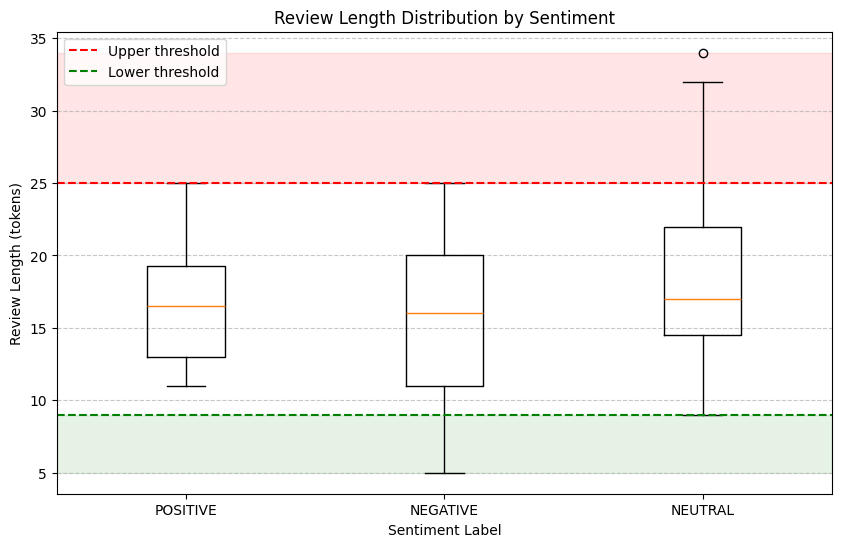

In [13]:
# Pattern-2 - Review length
df["review_length"] = df["review"].apply(lambda x: len(tokenize(x)))
pos_lengths = df[df["label"] == "Positive"]["review_length"]
neg_lengths = df[df["label"] == "Negative"]["review_length"]
neu_lengths = df[df["label"] == "Neutral"]["review_length"]

plt.figure(figsize=(10, 6))
plt.boxplot(
    [pos_lengths, neg_lengths, neu_lengths],
    tick_labels=["POSITIVE", "NEGATIVE", "NEUTRAL"],
    showfliers=True
)

plt.axhline(y=25, color='r', linestyle='--', label='Upper threshold')
y_max = max(pos_lengths.max(), neg_lengths.max(), neu_lengths.max())
plt.axhspan(25, y_max, color='r', alpha=0.1)

plt.axhline(y=9, color='g', linestyle='--', label='Lower threshold') 
y_min = min(pos_lengths.min(), neg_lengths.min(), neu_lengths.min())
plt.axhspan(y_min, 9, color='g', alpha=0.1)

plt.legend(loc='upper left')

plt.xlabel("Sentiment Label")
plt.ylabel("Review Length (tokens)")
plt.title("Review Length Distribution by Sentiment")
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

##### Summary - Review Length Distribution

In [14]:
df.groupby("label")["review_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
Negative,25.0,15.080000,5.453745,5.0,11.0,16.0,20.00,25.0
Neutral,47.0,18.404255,6.198385,9.0,14.5,17.0,22.00,34.0
Positive,28.0,16.785714,4.130798,11.0,13.0,16.5,19.25,25.0


### Part 2.2: Snorkel Labeling Functions

Wrap your heuristics as Snorkel @labeling_function decorators.
Each function should return POSITIVE (2), NEGATIVE (0), NEUTRAL (1), or ABSTAIN (-1).

In [17]:
# Lexicon of adjectives (manually curated based on top words and intuition)
pos_adj = "perfect|triumph|highly|recommended|hooked|performance|superb|wow|enjoy|miss|delivered|blown"


neg_adj = "horrible|terrible|awful|misfire|waste|avoid|garbage|failed|zero"


neu_adj = "okay|fine|middle|stupid|oscillated|categorize|forgettable|confused|rest|great"

In [18]:
@labeling_function()
def lf_keyword_great(x):
    """
    Example labeling function: Check if "great" appears in the review.
    Returns POSITIVE if found, otherwise ABSTAIN.
    """
    # TODO: Check if "great" (case-insensitive) is in x.review
    # Return POSITIVE if found, ABSTAIN otherwise

    #According to our gold_Standard dataset, a combination of 'great' and 'but' in the review results in a NEUTRAL label
    review_tokens = x.review.lower().split()
    if 'great' in review_tokens:
        if 'but' in review_tokens: return NEUTRAL
        else: return POSITIVE
    return ABSTAIN

@labeling_function()
def lf_short_review(x):
    """
    Label based on review length.
    Very short reviews might be neutral or indicate lack of engagement.
    """
    # TODO: Implement logic based on review length
    # Return appropriate label (NEUTRAL for very short, or ABSTAIN)
    if len(tokenize(x.review.lower())) <= 7:return NEGATIVE
    return ABSTAIN

@labeling_function()
def lf_regex_bad(x):
    """
    Use regex to find negative patterns.
    Look for words like "horrible", "terrible", "awful", etc.
    """
    # TODO: Use regex or string matching to find negative keywords
    # Return NEGATIVE if found, ABSTAIN otherwise
    negative_pattern = r"\b(horrible|terrible|awful|misfire|waste|avoid|garbage|failed|zero)\b"
    if re.search(negative_pattern, x.review.lower()):
        return NEGATIVE
    return ABSTAIN

# TODO: Write at least 3 more labeling functions (minimum 6 total)

@labeling_function()
def lf_long_review(x):
    """
    If review is longer than 27 non stop words, it tends to be neutral
    """
    if len(tokenize(x.review.lower())) >= 27: return NEUTRAL
    return ABSTAIN

@labeling_function()
def lf_regex_good(x):
    """
    Prescence of words like perfect, triumph, highly, recommended, etc are signs of clearly Positive reviews
    """
    positive_pattern = r"\b(perfect|triumph|highly|recommended|hooked|performance|superb|wow|enjoy|miss|delivered|blown)\b"
    if re.search(positive_pattern, x.review.lower()):
        return POSITIVE
    return ABSTAIN

@labeling_function()
def lf_regex_neutral(x):
    """
    Words like okay, fine, middle, oscillated in the review indicate a NEUTRAL review
    """
    neutral_pattern = r"\b(okay|fine|middle|stupid|oscillated|categorize|forgettable|confused|rest|great)\b"
    if re.search(neutral_pattern, x.review.lower()):
        return NEUTRAL
    return ABSTAIN

### Part 2.3: Apply Labeling Functions and Analyze Coverage

Apply all labeling functions to the 200 unlabeled reviews and calculate coverage and conflict rates.

In [19]:
def analyze_weak_labels(L_matrix, lfs):
    """
    Prints Coverage and Conflict statistics for the Labeling Functions.
    
    Args:
        L_matrix (np.array): Label matrix of shape (N_samples, N_functions)
                            Each column represents one labeling function's outputs
                            Values: POSITIVE (1), NEGATIVE (0), NEUTRAL (2), ABSTAIN (-1)
        lfs: List of labeling functions (for display names)
    
    Metrics to calculate:
        - Coverage: Percentage of non-abstain votes per LF
        - Conflict Rate: Percentage of samples where LFs disagree
    """
    # TODO: Calculate coverage for each labeling function
    # Coverage = (number of non-abstain votes) / (total samples) * 100
    n, m = L_matrix.shape
    for i in range(m):
        not_abstain = np.sum(L_matrix[:,i] != -1)
        coverage = (not_abstain / n) * 100
        print(f"Coverage of {lfs[i].name} : {coverage:.2f}%")
    
    # TODO: Calculate conflict rate
    # Conflict occurs when multiple LFs label the same sample differently
    # Conflict Rate = (number of conflicting samples) / (total samples) * 100
    conflict_cnt = 0
    for row in L_matrix:
        labels = row[row != -1]
        if len(labels) >= 2 and len(set(labels)) > 1:
            conflict_cnt+=1
    conflict_rate = (conflict_cnt/n) * 100
    print(f"Conflict Rate : {conflict_rate:.2f}%")

    # TODO: Print statistics in a readable format
    # Hint: Use LFAnalysis from snorkel for detailed stats (optional)
    # Or print manually: LF name, Coverage %, Conflicts count
    
       
    

# TODO: Load the 200 unlabeled reviews (you can load the entire dataset and then filter as per the requirement)
df_all = pd.read_csv("Movie_review.csv")
df_unlabelled = df_all[~df_all['review'].isin(df_gold_st['review'])].reset_index(drop=True)

# TODO: Apply all labeling functions to create L_matrix
lfs = [lf_keyword_great, lf_short_review, lf_regex_bad, lf_long_review, lf_regex_good, lf_regex_neutral]  # Add all your LFs
applier = PandasLFApplier(lfs=lfs)
L_matrix = applier.apply(df=df_unlabelled)

# TODO: Analyze coverage and conflicts
analyze_weak_labels(L_matrix, lfs)

# TODO: Use LFAnalysis for detailed statistics
print("Statistics using LFAnalysis:")
LFAnalysis(L=L_matrix, lfs=lfs).lf_summary()

100%|██████████| 220/220 [00:00<00:00, 9012.17it/s]

Coverage of lf_keyword_great : 1.36%
Coverage of lf_short_review : 0.91%
Coverage of lf_regex_bad : 14.09%
Coverage of lf_long_review : 5.45%
Coverage of lf_regex_good : 14.55%
Coverage of lf_regex_neutral : 29.09%
Conflict Rate : 2.27%
Statistics using LFAnalysis:


,j,Polarity,Coverage,Overlaps,Conflicts
lf_keyword_great,0,[1],0.013636,0.013636,0.000000
lf_short_review,1,[0],0.009091,0.009091,0.000000
lf_regex_bad,2,[0],0.140909,0.031818,0.022727
lf_long_review,3,[1],0.054545,0.045455,0.018182
lf_regex_good,4,[2],0.145455,0.000000,0.000000
lf_regex_neutral,5,[1],0.290909,0.054545,0.013636


### Part 2.4: Majority Vote Adjudication

Use majority vote to generate probabilistic labels (weak labels) for the 200 reviews.
Save the result to `weak_labels_200.csv`.

In [20]:
# TODO: Train LabelModel to get probabilistic labels
def majority_vote_probabilistic(L_matrix, num_classes=3):
    """
    Performs majority vote adjudication to produce probabilistic labels.
    Args:
        L_matrix (np.array): shape (N_samples, N_LFs)
                             values in {0,1,2,-1}
        num_classes (int): number of classes (default=3)
    Returns:
        probs (np.array): shape (N_samples, num_classes)
                          probabilistic weak labels
    """
    n_samples = L_matrix.shape[0]
    probs = np.zeros((n_samples, num_classes))

    for i in range(n_samples):
        row = L_matrix[i]
        votes = row[row != -1]   # ignore abstains

        if len(votes) == 0:
            # No LF voted → uniform distribution
            probs[i] = np.ones(num_classes) / num_classes
        else:
            for c in range(num_classes):
                probs[i, c] = np.sum(votes == c) / len(votes)
    return probs

# TODO: Convert numeric labels to match your label scheme
# Label mapping: 0 -> 'Negative' (or 0), 2 -> 'Positive' (or 2), 1 -> 'Neutral' (or 1), -1 -> 'Abstain'
prob_labels = majority_vote_probabilistic(L_matrix, num_classes=3)
weak_labels_df = pd.DataFrame(
    prob_labels,
    columns=["NEGATIVE", "NEUTRAL", "POSITIVE"]
)

# TODO: Create DataFrame with reviews and weak labels
weak_labels_df["review"] = df_unlabelled["review"].values
weak_labels_df[["NEGATIVE", "POSITIVE", "NEUTRAL"]] = weak_labels_df[["NEGATIVE", "POSITIVE", "NEUTRAL"]].round(2)

weak_labels_df = weak_labels_df[
    ["review", "NEGATIVE", "NEUTRAL", "POSITIVE"]
] #to reorder

# TODO: Save to CSV
weak_labels_df.to_csv("weak_labels_200.csv", index=False)

## Task 3: Active Learning (The Budget Optimizer) (5 Marks)

**Objective:** Simulate cost savings by training a model iteratively.

### Part 3.1: Query Strategy Implementation

Implement Least Confidence and Entropy Sampling from scratch.
These strategies select the most informative samples for labeling.

In [21]:
np.random.seed(7)

def least_confidence_sampling(model, X_pool, n_instances=10):
    """
    Selects samples where the model is least confident (uncertainty sampling).
    
    Args:
        model: Trained classifier with predict_proba() method
        X_pool: Feature matrix of unlabeled samples
        n_instances: Number of samples to select
    
    Returns:
        np.array: Indices of selected samples
        
    Strategy:
        Uncertainty = 1 - max(probability) across all classes
        For 3-class classification: Get probabilities for [Negative, Positive, Neutral]
        Select samples with highest uncertainty (lowest max probability)
    """
    # TODO: Get probability predictions from model
    probs = model.predict_proba(X_pool)
    
    # TODO: Calculate uncertainty: 1 - max(probability) for each sample
    uncertainty = 1 - np.max(probs, axis = 1)
    
    # TODO: Select top n_instances samples with highest uncertainty
    uncertainity_indices = np.argsort(uncertainty)[-n_instances:]
    
    return uncertainity_indices

def entropy_sampling(model, X_pool, n_instances=10):
    """
    Selects samples with highest entropy (information gain).
    
    Args:
        model: Trained classifier with predict_proba() method
        X_pool: Feature matrix of unlabeled samples
        n_instances: Number of samples to select
    
    Returns:
        np.array: Indices of selected samples
        
    Strategy:
        Entropy = -sum(p * log(p)) for all classes
        For 3-class classification: Calculate entropy across [Negative, Positive, Neutral] probabilities
        Select samples with highest entropy (most uncertain across all classes)
    """
    # TODO: Get probability predictions from model
    probs = model.predict_proba(X_pool)
    
    # TODO: Calculate entropy: -sum(p * log(p)) for each sample
    # Add small epsilon (1e-9) to avoid log(0) errors
    entropy = -np.sum(probs * np.log(probs + 1e-9), axis = 1)
    
    # TODO: Select top n_instances samples with highest entropy
    entropy_indices = np.argsort(entropy)[-n_instances:]
    
    return entropy_indices

def random_sampling(model, X_pool, n_instances=10):
    """
    Baseline strategy: Selects random samples.
    
    Args:
        model: Not used, but kept for interface consistency
        X_pool: Feature matrix of unlabeled samples
        n_instances: Number of samples to select
    
    Returns:
        np.array: Randomly selected indices
    """
    # TODO: Randomly select n_instances indices from X_pool
    return np.random.choice(len(X_pool), size = n_instances, replace = False)

### Part 3.2: Data Processing and Setup

Load the gold standard (seed) and weak labels (pool).
Create a static test set from the pool for evaluation.
Vectorize text data using TF-IDF.

In [26]:
df_seed = pd.read_csv('gold_standard_100.csv')
label_col_seed = 'label' if 'label' in df_seed.columns else 'sentiment'
print(df_seed[label_col_seed].dtype)
df_seed[label_col_seed].dtype == object

str


False

In [22]:
def load_and_process_data():
    """
    Loads and processes data for active learning.
    
    Returns:
        Tuple: (X_seed, y_seed, X_pool, y_pool, X_test, y_test, vectorizer)
               All X are feature matrices, all y are label arrays
               vectorizer is returned for later use on LLM data
               
    Note:
        - Seed: gold_standard_100.csv (100 labeled reviews)
        - Pool: weak_labels_200.csv (200 reviews, labels treated as hidden for simulation)
        - Test: Hold out 50 samples from pool (weak labels) for static evaluation
        - We use 3-class classification: Positive (1), Negative (0), Neutral (2)
        - Uncertainty metrics use probability scores across all three classes:
          * Least Confidence: 1 - max(probabilities) across all classes
          * Entropy: -sum(p * log(p)) for all three classes
    """

    df_seed = pd.read_csv('gold_standard_100.csv')
    df_pool_full = pd.read_csv('weak_labels_200.csv')

    #Since the weak_labels_200.csv has only probabilistic labels and no 'label' column, we add the ground truth
    #labels to it to use later to simulate active labelling

    prob_cols = ['NEGATIVE', 'NEUTRAL', 'POSITIVE']
    if not all(col in df_pool_full.columns for col in prob_cols):
        raise ValueError("These columns should be in the weak_labels_200.csv:", prob_cols)
    
    probs = df_pool_full[prob_cols].values #creates a NP array of the three columns
    max_probs = np.max(probs, axis = 1)
    confidence_mask = max_probs > 0.5

    df_pool_filtered = df_pool_full[confidence_mask].copy()
    df_pool_filtered['label'] = np.argmax(df_pool_filtered[prob_cols].values, axis = 1)

    removed_count = len(df_pool_full) - len(df_pool_filtered)
    print(f"Filtered Pool Size: {len(df_pool_filtered)} (Removed {removed_count} uncertain samples)")

    #to keep naming constant:
    df_pool_full = df_pool_filtered
    
    # Ensure both have 'review' column
    if 'review' not in df_seed.columns:
        raise ValueError("gold_standard_100.csv must have 'review' column")
    if 'review' not in df_pool_full.columns:
        raise ValueError("weak_labels_200.csv must have 'review' column")
    
    # Handle both 'label' and 'sentiment' column names
    label_col_seed = 'label' if 'label' in df_seed.columns else 'sentiment'
    label_col_pool = 'label' if 'label' in df_pool_full.columns else 'sentiment'
    
    # Map text labels to numeric: Positive=1, Negative=0, Neutral=2
    label_mapping = {
        'Positive': 2, 'positive': 2, 'POSITIVE': 2,
        'Negative': 0, 'negative': 0, 'NEGATIVE': 0,
        'Neutral': 1, 'neutral': 1, 'NEUTRAL': 1
    }
    
    # Convert seed labels
    if (df_seed[label_col_seed].dtype == 'object') | (df_seed[label_col_seed].dtype == 'str'):
        df_seed['sentiment_numeric'] = df_seed[label_col_seed].str.strip().map(label_mapping)
        if df_seed['sentiment_numeric'].isna().any():
            raise ValueError(f"Unknown labels in seed data: {df_seed[df_seed['sentiment_numeric'].isna()][label_col_seed].unique()}")
    else:
        df_seed['sentiment_numeric'] = df_seed[label_col_seed].values
    
    # Convert pool labels
    if df_pool_full[label_col_pool].dtype == 'object':
        df_pool_full['sentiment_numeric'] = df_pool_full[label_col_pool].map(label_mapping)
        if df_pool_full['sentiment_numeric'].isna().any():
            raise ValueError(f"Unknown labels in pool data: {df_pool_full[df_pool_full['sentiment_numeric'].isna()][label_col_pool].unique()}")
    else:
        df_pool_full['sentiment_numeric'] = df_pool_full[label_col_pool].values
    
    # Create static test set (hold out 50 samples from pool)
    df_pool, df_test = train_test_split(df_pool_full, test_size=50, random_state=42)
    
    # Vectorize text data using TfidfVectorizer
    # Fit vectorizer on ALL text (seed + pool + test) to ensure consistent dimensions
    vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
    all_text = pd.concat([df_seed['review'], df_pool['review'], df_test['review']])
    vectorizer.fit(all_text)

    # Transform datasets to feature matrices
    X_seed = vectorizer.transform(df_seed['review']).toarray()
    X_pool = vectorizer.transform(df_pool['review']).toarray()
    X_test = vectorizer.transform(df_test['review']).toarray()
    
    # Extract numeric labels
    y_seed = df_seed['sentiment_numeric'].values.astype(int)
    y_pool = df_pool['sentiment_numeric'].values.astype(int)
    y_test = df_test['sentiment_numeric'].values.astype(int)
    
    # Return all datasets and vectorizer
    return X_seed, y_seed, X_pool, y_pool, X_test, y_test, vectorizer

# TODO: uncomment below codes, to use these variables further
X_seed, y_seed, X_pool, y_pool, X_test, y_test, vectorizer = load_and_process_data()

print(f"Seed Size: {len(y_seed)}")
print(f"Pool Size: {len(y_pool)} (Available for querying)")
print(f"Test Size: {len(y_test)} (Held out for evaluation)")

Filtered Pool Size: 123 (Removed 97 uncertain samples)
Seed Size: 100
Pool Size: 73 (Available for querying)
Test Size: 50 (Held out for evaluation)


### Part 3.3: Active Learning Loop

Implement the iterative active learning loop:
1. Train model on current training set
2. Query uncertain samples from pool
3. "Label" them (reveal ground truth)
4. Add to training set and retrain
5. Log test accuracy

In [25]:
def run_active_learning_loop(X_seed, y_seed, X_pool, y_pool, X_test, y_test, 
                             strategy_func, steps=5, batch_size=10):
    """
    Simulates the active learning loop (matches lab approach).
    
    Args:
        X_seed, y_seed: Initial training data (seed set)
        X_pool, y_pool: Unlabeled pool (y_pool is hidden, revealed during query)
        X_test, y_test: Static test set for evaluation
        strategy_func: Function that selects samples (e.g., least_confidence_sampling)
                      Signature: strategy_func(model, X_pool, n_instances) -> indices
        steps: Number of iterations
        batch_size: Number of samples to query per iteration
    
    Returns:
        Tuple: (n_labels_history, accuracy_history)
               Lists tracking number of labels and test accuracy over iterations
    """
    # TODO: Initialize training set with seed data
    X_train = X_seed.copy()
    y_train = y_seed.copy()
    
    # TODO: Create working copies of pool (we'll remove samples as we query them)
    X_pool_curr = X_pool.copy()
    y_pool_curr = y_pool.copy()
    
    # TODO: Initialize empty lists to track progress (accuracy_history, n_labels_history)
    acc_hist = []
    n_labels_hist = []
    
    # Train initial model on seed data
    model = LogisticRegression(solver='lbfgs', max_iter=1000)
    model.fit(X_train, y_train)
    
    # TODO: Evaluate initial model and log results
    initial_acc = accuracy_score(y_test, model.predict(X_test))
    
    # Log the starting point
    n_labels_hist.append(len(y_train))
    acc_hist.append(initial_acc)
    print(f"Initial Accuracy (Seed only): {initial_acc:.4f}")
    
    # TODO: Iterative loop (repeat 'steps' times):
    #   for i in range(steps):
    #       1. Query: Use strategy_func(model, X_pool_curr, batch_size) to get indices
    #       2. "Label": Reveal ground truth: y_new = y_pool_curr[query_indices]
    #       3. Add to training set: use np.vstack() to add new samples
    #       4. Remove from pool: use np.delete() to remove queried samples
    #       5. Retrain model: use model.fit() to update the model
    #       6. Evaluate on test set, get accuracy
    #       7. Log: accuracy_history.append(acc), n_labels_history.append(len(y_train))
    for i in range (steps):
        curr_batch_size = min(batch_size, len(y_pool_curr))
        if curr_batch_size == 0:
            print("Pool exhausted")
            break
        query = strategy_func(model, X_pool_curr, curr_batch_size)
        X_new = X_pool_curr[query]
        y_new = y_pool_curr[query]

        X_train = np.vstack((X_train, X_new))
        y_train = np.concatenate((y_train, y_new)) #np.vstack expects 2D array, y is 1D, so we use concat instead

        X_pool_curr = np.delete(X_pool_curr, query, axis=0)
        y_pool_curr = np.delete(y_pool_curr, query)

        model.fit(X_train, y_train)

        acc = accuracy_score(y_test, model.predict(X_test))
        
        n_labels_hist.append(len(y_train))
        acc_hist.append(acc)

        print(f"Step {i+1}: Added {len(y_new)} samples. Train Size: {len(y_train)}. Accuracy: {acc:.4f}")
    
    # TODO: Return history lists
    return n_labels_hist, acc_hist

# TODO: Run active learning with least confidence strategy
print("--- Active Learning (Least Confidence) ---")
n_labels_lc, acc_lc = run_active_learning_loop(
    X_seed, y_seed, X_pool, y_pool, X_test, y_test, 
    strategy_func=least_confidence_sampling, 
    steps=5,
    batch_size=10   # Pick 10 reviews per round
)

--- Active Learning (Least Confidence) ---
Initial Accuracy (Seed only): 0.9800
Step 1: Added 10 samples. Train Size: 110. Accuracy: 1.0000
Step 2: Added 10 samples. Train Size: 120. Accuracy: 1.0000
Step 3: Added 10 samples. Train Size: 130. Accuracy: 1.0000
Step 4: Added 10 samples. Train Size: 140. Accuracy: 1.0000
Step 5: Added 10 samples. Train Size: 150. Accuracy: 1.0000


### Part 3.4: Visualization and Comparison

Plot learning curves comparing Active Learning vs. Random Sampling.


--- Running Random Sampling (Baseline) ---
Initial Accuracy (Seed only): 0.9800
Step 1: Added 10 samples. Train Size: 110. Accuracy: 0.9800
Step 2: Added 10 samples. Train Size: 120. Accuracy: 0.9800
Step 3: Added 10 samples. Train Size: 130. Accuracy: 1.0000
Step 4: Added 10 samples. Train Size: 140. Accuracy: 1.0000
Step 5: Added 10 samples. Train Size: 150. Accuracy: 0.9800


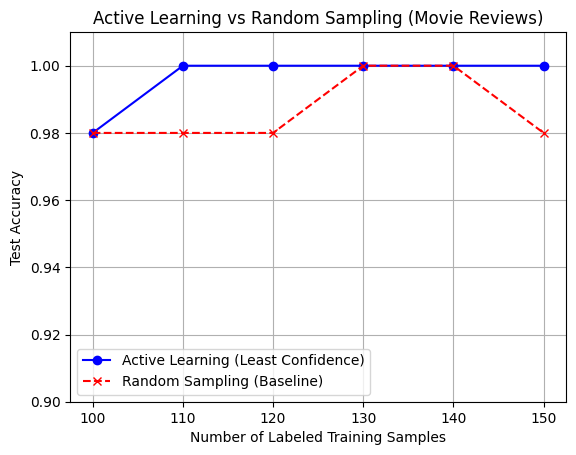

------------------------------
FINAL ACCURACY COMPARISON
------------------------------
Initial Accuracy (Seed): 0.9800
Final AL Accuracy:       1.0000
Final Random Accuracy:   0.9800
------------------------------
AL gained 2.00% accuracy.
Random gained 0.00% accuracy.


In [38]:
np.random.seed(7)
# TODO: Run active learning with random sampling (baseline)
print("\n--- Running Random Sampling (Baseline) ---")
n_labels_rand, acc_rand = run_active_learning_loop(
    X_seed, y_seed, X_pool, y_pool, X_test, y_test, 
    strategy_func=random_sampling, 
    steps=5, 
    batch_size=10
)
# TODO: Plot learning curves of active learning and random sampling wrt to number of samples
plt.plot(n_labels_lc, acc_lc, marker='o', color='blue', label='Active Learning (Least Confidence)')
plt.plot(n_labels_rand, acc_rand, marker='x', linestyle='--', color='red', label='Random Sampling (Baseline)')
plt.title('Active Learning vs Random Sampling (Movie Reviews)')
plt.xlabel('Number of Labeled Training Samples')
plt.ylabel('Test Accuracy')
plt.ylim(0.9, 1.01)
plt.legend()
plt.grid(True)
plt.show()

# TODO: Print comparison summary for active learning and random sampling final accuracy
print("-" * 30)
print("FINAL ACCURACY COMPARISON")
print("-" * 30)
print(f"Initial Accuracy (Seed): {acc_lc[0]:.4f}")
print(f"Final AL Accuracy:       {acc_lc[-1]:.4f}")
print(f"Final Random Accuracy:   {acc_rand[-1]:.4f}")
print("-" * 30)

improvement_al = acc_lc[-1] - acc_lc[0]
improvement_rand = acc_rand[-1] - acc_rand[0]

print(f"AL gained {improvement_al*100:.2f}% accuracy.")
print(f"Random gained {improvement_rand*100:.2f}% accuracy.")

## Task 4: AI vs. AI (LLM & Noise Detection) (3 Marks)

**Objective:** Use LLMs for bulk labeling and detect hallucinations.

**Note:**

- Make an account at [open-router](https://openrouter.ai/) and get the API key.
- Use `google/gemini-2.5-flash-lite` (free tier) model as your LLM. Read the documentation on how to use it [here](https://openrouter.ai/google/gemini-2.5-flash-lite/api)
- Set environment variable using .env file and paste your API key in it.

### Part 4.1: LLM Pipeline with Few-Shot Prompting

Design a few-shot prompt with 3 examples from gold standard.
Send remaining unlabeled samples (~150) to Gemini API for labeling.

In [31]:

import os
import time
import json
import requests
import pandas as pd
from dotenv import load_dotenv

load_dotenv()
API_KEY = os.getenv('OPENROUTER_API_KEY')
SITE_URL = "http://localhost:8000"  #for OpenRouter rankings
SITE_NAME = "Student Lab Assignment"

MODEL_NAME = "google/gemini-2.5-flash-lite"

if not API_KEY:
    print("Warning: OPENROUTER_API_KEY not found. Please check your .env file.")

#### [EXTRA] Testing the OpenRouter API

In [32]:
import requests
import json

# Copied directly from OpenRouter API documentation for Gemini-2.5-flash-lite

response = requests.post(
  url="https://openrouter.ai/api/v1/chat/completions",
  headers={
    "Authorization": f"Bearer {API_KEY}",
    "Content-Type": "application/json",
    "HTTP-Referer": f"{SITE_URL}", # Optional. Site URL for rankings on openrouter.ai.
    "X-Title": f"{SITE_NAME}", # Optional. Site title for rankings on openrouter.ai.
  },
  data=json.dumps({
    "model": "google/gemini-2.5-flash-lite",
    "messages": [
      {
        "role": "user",
        "content": [
          {
            "type": "text",
            "text": "What is in this image?"
          },
          {
            "type": "image_url",
            "image_url": {
              "url": "https://live.staticflickr.com/3851/14825276609_098cac593d_b.jpg" # image of a dolphin
            }
          }
        ]
      }
    ]
  })
)

if response.status_code == 200:
    data = response.json()
    print("Model Response:")
    print(json.dumps(data, indent=2))
else:
    print(f"Error: {response.status_code} - {response.text}")

Model Response:
{
  "id": "gen-1771237546-gsPfa5gmfZJdxzdWLhcZ",
  "provider": "Google",
  "model": "google/gemini-2.5-flash-lite",
  "object": "chat.completion",
  "created": 1771237546,
  "choices": [
    {
      "logprobs": null,
      "finish_reason": "stop",
      "native_finish_reason": "STOP",
      "index": 0,
      "message": {
        "role": "assistant",
        "content": "In the image, there are two dolphins swimming in the ocean. The dolphin in the foreground is leaping out of the water with a splash. The dolphin in the background is partially submerged in the water. Both dolphins are gray with white undersides. The water is blue and choppy.",
        "refusal": null,
        "reasoning": null,
        "annotations": []
      }
    }
  ],
  "usage": {
    "prompt_tokens": 1812,
    "completion_tokens": 56,
    "total_tokens": 1868,
    "cost": 0.0002036,
    "is_byok": false,
    "prompt_tokens_details": {
      "cached_tokens": 0,
      "cache_write_tokens": 0,
      "au

In [33]:
# Extracting the model's response text
try:
    model_reply = data['choices'][0]['message']['content']
    print("\nModel's Answer:")
    print(model_reply)
except (KeyError, IndexError) as e:
    print("Error extracting model response:", e)


Model's Answer:
In the image, there are two dolphins swimming in the ocean. The dolphin in the foreground is leaping out of the water with a splash. The dolphin in the background is partially submerged in the water. Both dolphins are gray with white undersides. The water is blue and choppy.


In [34]:
# Part 4.1: LLM Pipeline with Few-Shot Prompting
def generate_few_shot_prompt(review_text, examples):
    """
    Constructs a few-shot prompt with 3 gold examples + target review.
    
    Args:
        review_text (str): The review to be labeled
        examples (list): List of 3 example dictionaries with 'review' and 'label' keys
    
    Returns:
        str: Formatted prompt string
    """
    
    prompt = "You are a movie review sentiment classifier. Classify the sentiment of the given review as 'Positive', 'Negative', or 'Neutral'.\n\n"
    
    for i, ex in enumerate(examples, 1):
        prompt += f"Example {i}:\nReview: {ex['review']}\nLabel: {ex['label']}\n\n"

    prompt += f"Target Review: {review_text}\nLabel:"

    return prompt


def query_openrouter(review_text, examples):
    """
    Sends request to OpenRouter API with retry logic and parsing.
    
    Args:
        review_text (str): Review to classify
        examples (list): Few-shot examples (list of dicts with 'review' and 'label')
    
    Returns:
        str: Label ('Positive', 'Negative', or 'Neutral')
             Returns None if API fails or response is invalid
    
    Note:
        - Uses OpenRouter API endpoint: https://openrouter.ai/api/v1/chat/completions
        - Implements retry logic for rate limit errors (429)
        - Parses response from OpenRouter's chat completions format
    """
    url = "https://openrouter.ai/api/v1/chat/completions"
    

    # TODO: Set up headers:
    # (identified the headers from the docs)
    headers={
        "Authorization": f"Bearer {API_KEY}",
        "Content-Type": "application/json",
        "HTTP-Referer": f"{SITE_URL}", 
        "X-Title": f"{SITE_NAME}", 
    }
    

    # TODO: Generate prompt using generate_few_shot_prompt()
    prompt = generate_few_shot_prompt(review_text, examples)
    
    # TODO: Create payload dictionary:
    payload = {
        "model": MODEL_NAME,
        "messages": [
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": prompt
                    }
                ]
            }
        ]
    }
    

    # TODO: Implement retry logic:
    max_retries = 5
    for attempt in range(max_retries):
        response = requests.post(url, headers=headers, data=json.dumps(payload))
        
        # Successful
        if response.status_code == 200:
            break

        # Rate limit error
        elif response.status_code == 429:
            wait_time = 2 ** attempt  # Exponential backoff: 1s, 2s, 4s...
            print(f"Rate limit hit. Waiting for {wait_time} seconds before retrying...")
            time.sleep(wait_time)

        # Other errors
        else:
            print(f"Error: Received status code {response.status_code}")
            print(f"Response: {response.text}")
            return None
    

    # TODO: Parse successful response:
    response_json = response.json()
    try:
        generated_text = response_json['choices'][0]['message']['content'].strip()
        if generated_text in ['Positive', 'Negative', 'Neutral']:
            return generated_text
        else:
            print(f"Unexpected label in response: '{generated_text}'")
            return None
    except (KeyError, IndexError) as e:
        print(f"Error parsing response: {e}\n")
        print(f"Full response:\n\n{response_json}")
        return None

In [49]:
from tqdm import tqdm
# --- MAIN EXECUTION ---
DO_LLM_LABELLING = True
OVERWRITE_CSV = True

# TODO: Load gold standard examples for few-shot prompting

gold_examples = df_gold_st.iloc[[2,8,16]].to_dict('records') # List[Dict], handpicked one from each sentiment category

prompt_template = generate_few_shot_prompt("This is a sample review.", gold_examples)
print("--------Sample Few-Shot Prompt:--------\n")
print(prompt_template)
print("---------------------------------------\n")

# TODO: Load remaining unlabeled reviews (~150, select last 150 from movie_reviews_300.csv)
unlabeled_reviews = pd.read_csv("Movie_review.csv")['review'].tolist()[-150:]

# TODO: Query OpenRouter for each review
# Handle free tier requests per minute (RPM) limit of ~15
y_llm_labels = []
for i, review in tqdm(enumerate(unlabeled_reviews)):
    if not DO_LLM_LABELLING:
        print("DO_LLM_LABELLING = False")
        break

    label = query_openrouter(review, gold_examples)
    if label is None:
        print("Error encountered, exiting...")
        break
    y_llm_labels.append({'review': review, 'label': label})
    
    # To respect RPM limits (worst case 3 requests made by one query_openrouter call, so we make 5 calls per minute to be safe)
    time.sleep(2)

if not DO_LLM_LABELLING: print(f"{len(unlabeled_reviews)} reviews labelled successfully!")

# TODO: Save LLM labels, in csv format with 'review' and 'label' columns
df_llm_labels = pd.DataFrame(y_llm_labels)
LLM_CSV_PATH = "llm_labels_150.csv"
if OVERWRITE_CSV:
    df_llm_labels.to_csv(LLM_CSV_PATH, index=False)
    print(f"Saved at {LLM_CSV_PATH}")
else:
    print("Overwriting disabled. Perhaps llm_labels.csv already populated.")

--------Sample Few-Shot Prompt:--------

You are a movie review sentiment classifier. Classify the sentiment of the given review as 'Positive', 'Negative', or 'Neutral'.

Example 1:
Review: I was completely blown away by this film. The lead actor delivered a refreshing performance. I will be thinking about this for days.
Label: Positive

Example 2:
Review: It’s not a masterpiece, but it’s not a disaster either. The acting is fine, but the editing is a bit serviceable. You won't remember it a week from now.
Label: Neutral

Example 3:
Review: Total garbage. Zero stars if I could give it.
Label: Negative

Target Review: This is a sample review.
Label:
---------------------------------------



150it [08:48,  3.53s/it]

Saved at llm_labels_150.csv


### Part 4.2: Noise Hunting (Cleanlab Logic)

Train a Logistic Regression model on LLM-labeled data.
Identify "High Confidence Disagreements" where the model is very confident (>0.80) but disagrees with the LLM label.

In [50]:
def find_label_errors(llm_labels, model_probs, review_texts, threshold=0.80):
    """
    Detects high-confidence disagreements between model predictions and LLM labels.
    This implements Cleanlab logic: find cases where model is confident but disagrees with LLM.
    
    Args:
        llm_labels: List/array of labels from Gemini (numeric: 0=Negative, 2=Positive, 1=Neutral)
        model_probs: Probability matrix from Logistic Regression (shape: N_samples, N_classes)
        review_texts: List of review texts (for display)
        threshold: Confidence threshold (default 0.90)
    
    Returns:
        list: List of dictionaries with suspicious review information
              Each dict contains: 'index', 'text', 'llm_label', 'model_pred', 'confidence'
    """
    # TODO: Get model predictions from probabilities
    preds = model_probs.argmax(axis=1)
    
    # TODO: Get model confidence (max probability) for each sample
    confs = model_probs.max(axis=1)

    # TODO: Convert llm_labels to numeric if they are strings
    # Map 'Positive'->1, 'Negative'->0, 'Neutral'->2
    if len(llm_labels) == 0:
        return []

    if isinstance(llm_labels[0], str):
        label_mapping = {
            'Negative': 0, 'negative': 0, 'NEGATIVE': 0,
            'Positive': 2, 'positive': 2, 'POSITIVE': 2,
            'Neutral': 1, 'neutral': 1, 'NEUTRAL': 1,
        }
        llm_labels_numeric = [label_mapping.get(l, None) for l in llm_labels]
        if any(v is None for v in llm_labels_numeric):
            unknown = sorted({llm_labels[i] for i, v in enumerate(llm_labels_numeric) if v is None})
            raise ValueError(f"Unknown labels found in llm_labels: {unknown}")
        llm_labels_numeric = np.array(llm_labels_numeric)
    else:
        # labels are already numeric
        llm_labels_numeric = np.array(llm_labels)

    # TODO: Find disagreements where:
    #   Hint: disagreement_mask = (preds != llm_labels) & (confidences > threshold)
    disagreement_mask = (preds != llm_labels_numeric) & (confs > threshold)

    # TODO: Create list of suspicious reviews with all relevant information (llm label, model prediction, confidence)
    suspicious_reviews = []
    for i, flag in enumerate(disagreement_mask):
        if flag:
            suspicious_reviews.append({
                'index': i,
                'text': review_texts[i],
                'llm_label': llm_labels_numeric[i],
                'model_pred': preds[i],
                'confidence': confs[i]
            })

    # TODO: Sort by confidence (highest first) to find most egregious errors
    suspicious_reviews = sorted(suspicious_reviews, key=lambda x: x['confidence'], reverse=True)

    # TODO: Return list of suspicious reviews
    return suspicious_reviews


# TODO: Load LLM labels in dataframe
_df_llm = pd.read_csv("llm_labels.csv")
llm_reviews = _df_llm["review"].tolist()
y_llm_labels = _df_llm["label"].tolist()

# TODO: Vectorize LLM-labeled reviews (use same vectorizer from Task 3)
X_llm = vectorizer.transform(llm_reviews).toarray()

# TODO: Train Logistic Regression on LLM-labeled data
# Use same model configuration as Task 3 for consistency
model = LogisticRegression(solver='lbfgs', max_iter=1000)

if isinstance(y_llm_labels[0], str):
    label_mapping = {
        'Negative': 0, 'negative': 0, 'NEGATIVE': 0,
        'Positive': 2, 'positive': 2, 'POSITIVE': 2,
        'Neutral': 1, 'neutral': 1, 'NEUTRAL': 1,
    }
    y_train = [label_mapping.get(lbl, None) for lbl in y_llm_labels]
    if any(v is None for v in y_train):
        unknown = sorted({y_llm_labels[i] for i, v in enumerate(y_train) if v is None})
        raise ValueError(f"Unknown labels found in llm_labels.csv: {unknown}")
    y_train = np.array(y_train)
else:
    y_train = np.array(y_llm_labels)

model.fit(X_llm, y_train)

# TODO: Get probabilities on the same data (self-check), shape should be (N_samples, N_classes)
model_probs = model.predict_proba(X_llm)

# TODO: Find label errors using your function
suspicious_reviews = find_label_errors(y_llm_labels, model_probs, llm_reviews, threshold=0.80)

# TODO: Print top 5 suspicious reviews (if <5, print all)
num_to_print = min(5, len(suspicious_reviews))
print(f"Top {num_to_print} Most Suspicious Reviews:")
print("=" * 60)
reverse_mapping = {0: 'Negative', 2: 'Positive', 1: 'Neutral'}

for i, review_info in enumerate(suspicious_reviews[:num_to_print], 1):
    print(f"Suspicious Review #{i}")
    print(f"Index: {review_info['index']}")
    text = review_info['text']
    print(f"Review: {text[:150]}..." if len(text) > 150 else f"Review: {text}")
    print(f"LLM Label: {reverse_mapping.get(review_info['llm_label'], review_info['llm_label'])}")
    print(f"Model Prediction: {reverse_mapping.get(review_info['model_pred'], review_info['model_pred'])}")
    print(f"Model Confidence: {review_info['confidence']:.4f}")
    print("-" * 80)

print(f"\nTotal suspicious reviews found: {len(suspicious_reviews)}")


Top 0 Most Suspicious Reviews:

Total suspicious reviews found: 0


## Deliverables

**Submission Checklist:**
- [ ] Completed Jupyter Notebook with all tasks (Tasks 1-4)
- [ ] Include your label-studio annotation interface screenshot.
- [ ] gold_standard_100.csv
- [ ] weak_labels_200.csv
- [ ] llm_labels_150.json